In [1]:
import pandas as pd
import numpy as np
import joblib
import time

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [2]:
X_train = pd.read_pickle("../../data/processed/X_train.pkl")
X_test = pd.read_pickle("../../data/processed/X_test.pkl")

X_train_scaled = pd.read_pickle("../../data/processed/X_train_scaled.pkl")
X_test_scaled = pd.read_pickle("../../data/processed/X_test_scaled.pkl")

y_train = pd.read_pickle("../../data/processed/y_train.pkl")
y_test = pd.read_pickle("../../data/processed/y_test.pkl")

print("Data loaded successfully.")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled:", X_test_scaled.shape)

Data loaded successfully.
X_train: (472432, 421)
X_test: (118108, 421)
X_train_scaled: (472432, 421)
X_test_scaled: (118108, 421)


In [3]:
def evaluate_model(model_name, model, X_train_data, X_test_data, y_train, y_test):
    start_time = time.time()
    
    model.fit(X_train_data, y_train)
    
    training_time = time.time() - start_time
    
    y_pred = model.predict(X_test_data)
    y_proba = model.predict_proba(X_test_data)[:, 1]
    
    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "Training Time (s)": round(training_time, 2)
    }
    
    print(f"\n{model_name} Results")
    print("=" * 40)
    print(classification_report(y_test, y_pred, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    
    return results, model

In [4]:
# ==========================================
# Logistic Regression Baseline Model
# ==========================================

log_reg = LogisticRegression(
    solver="saga",
    max_iter=1000,
    class_weight="balanced",
    random_state=42,
    verbose=1
)

start_time = time.time()

log_reg.fit(X_train_scaled, y_train)

training_time = time.time() - start_time

# Predictions
y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

# Display Results
print("=" * 60)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 60)

print(f"Accuracy      : {accuracy:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"Recall        : {recall:.4f}")
print(f"F1 Score      : {f1:.4f}")
print(f"ROC-AUC       : {roc_auc:.4f}")
print(f"Training Time : {training_time:.2f} seconds")

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

# Save results
logistic_results = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "Accuracy": [accuracy],
    "Precision": [precision],
    "Recall": [recall],
    "F1 Score": [f1],
    "ROC-AUC": [roc_auc],
    "Training Time (s)": [training_time]
})

logistic_results

max_iter reached after 4725 seconds


C:\Users\USER\Desktop\ai-fintech-platform\backend\.venv\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


LOGISTIC REGRESSION RESULTS
Accuracy      : 0.8283
Precision     : 0.1361
Recall        : 0.7302
F1 Score      : 0.2294
ROC-AUC       : 0.8615
Training Time : 4737.48 seconds

Classification Report
              precision    recall  f1-score   support

           0       0.99      0.83      0.90    113975
           1       0.14      0.73      0.23      4133

    accuracy                           0.83    118108
   macro avg       0.56      0.78      0.57    118108
weighted avg       0.96      0.83      0.88    118108


Confusion Matrix
[[94816 19159]
 [ 1115  3018]]


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time (s)
0,Logistic Regression,0.828344,0.136087,0.73022,0.229418,0.861538,4737.476693


In [5]:
from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    max_depth=12,
    min_samples_split=100,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42
)

dt_results, dt_model = evaluate_model(
    "Decision Tree",
    decision_tree,
    X_train,
    X_test,
    y_train,
    y_test
)

dt_results


Decision Tree Results
              precision    recall  f1-score   support

           0       0.99      0.87      0.93    113975
           1       0.17      0.77      0.28      4133

    accuracy                           0.86    118108
   macro avg       0.58      0.82      0.60    118108
weighted avg       0.96      0.86      0.90    118108

Confusion Matrix:
[[98983 14992]
 [  969  3164]]


{'Model': 'Decision Tree',
 'Accuracy': 0.864860974701121,
 'Precision': 0.17426745979290592,
 'Recall': 0.7655456085168159,
 'F1 Score': 0.2839068598860424,
 'ROC-AUC': 0.8771870860885854,
 'Training Time (s)': 89.1}

In [6]:
from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=100,
    min_samples_leaf=50,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_results, rf_model = evaluate_model(
    "Random Forest",
    random_forest,
    X_train,
    X_test,
    y_train,
    y_test
)

rf_results


Random Forest Results
              precision    recall  f1-score   support

           0       0.99      0.88      0.93    113975
           1       0.19      0.77      0.31      4133

    accuracy                           0.88    118108
   macro avg       0.59      0.83      0.62    118108
weighted avg       0.96      0.88      0.91    118108

Confusion Matrix:
[[100498  13477]
 [   955   3178]]


{'Model': 'Random Forest',
 'Accuracy': 0.8778067531411928,
 'Precision': 0.19081356949864905,
 'Recall': 0.7689329784660053,
 'F1 Score': 0.30575331922262844,
 'ROC-AUC': 0.9050141014810947,
 'Training Time (s)': 144.64}

In [7]:
model_results = pd.DataFrame([
    logistic_results.iloc[0].to_dict(),
    dt_results,
    rf_results
])

model_results.sort_values("ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time (s)
2,Random Forest,0.877807,0.190814,0.768933,0.305753,0.905014,144.640000
1,Decision Tree,0.864861,0.174267,0.765546,0.283907,0.877187,89.100000
0,Logistic Regression,0.828344,0.136087,0.730220,0.229418,0.861538,4737.476693


In [8]:
import os
import joblib

os.makedirs("../../ml/models", exist_ok=True)

joblib.dump(rf_model, "../../ml/models/random_forest_baseline.pkl")

print("Random Forest baseline model saved successfully.")

Random Forest baseline model saved successfully.


In [9]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
    random_state=42,
    n_jobs=-1
)

xgb_results, xgb_model = evaluate_model(
    "XGBoost",
    xgb_model,
    X_train,
    X_test,
    y_train,
    y_test
)

xgb_results


XGBoost Results
              precision    recall  f1-score   support

           0       0.99      0.91      0.95    113975
           1       0.25      0.82      0.38      4133

    accuracy                           0.91    118108
   macro avg       0.62      0.86      0.67    118108
weighted avg       0.97      0.91      0.93    118108

Confusion Matrix:
[[103831  10144]
 [   763   3370]]


{'Model': 'XGBoost',
 'Accuracy': 0.9076523182172249,
 'Precision': 0.24937102264318484,
 'Recall': 0.815388337769175,
 'F1 Score': 0.38193460644868815,
 'ROC-AUC': 0.937228166958182,
 'Training Time (s)': 78.44}

In [10]:
joblib.dump(xgb_model, "../../ml/models/xgboost_baseline.pkl")

print("XGBoost baseline model saved successfully.")

XGBoost baseline model saved successfully.


In [11]:
model_results = pd.DataFrame([
    logistic_results.iloc[0].to_dict(),
    dt_results,
    rf_results,
    xgb_results
])

model_results.sort_values("ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time (s)
3,XGBoost,0.907652,0.249371,0.815388,0.381935,0.937228,78.440000
2,Random Forest,0.877807,0.190814,0.768933,0.305753,0.905014,144.640000
1,Decision Tree,0.864861,0.174267,0.765546,0.283907,0.877187,89.100000
0,Logistic Regression,0.828344,0.136087,0.730220,0.229418,0.861538,4737.476693


In [12]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

lgbm_results, lgbm_model = evaluate_model(
    "LightGBM",
    lgbm_model,
    X_train,
    X_test,
    y_train,
    y_test
)

lgbm_results

[LightGBM] [Info] Number of positive: 16530, number of negative: 455902
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.557905 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 37870
[LightGBM] [Info] Number of data points in the train set: 472432, number of used features: 419
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000

LightGBM Results
              precision    recall  f1-score   support

           0       0.99      0.93      0.96    113975
           1       0.30      0.84      0.44      4133

    accuracy                           0.93    118108
   macro avg       0.65      0.88      0.70    118108
weighted avg       0.97      0.93      0.94    118108

Confusion Matrix:
[[105820   8155]
 [   673   3460]]


{'Model': 'LightGBM',
 'Accuracy': 0.9252548514918549,
 'Precision': 0.2978906586310805,
 'Recall': 0.8371642874425357,
 'F1 Score': 0.4394208788417577,
 'ROC-AUC': 0.9537106178970167,
 'Training Time (s)': 83.63}

In [13]:
joblib.dump(lgbm_model, "../../ml/models/lightgbm_baseline.pkl")

print("LightGBM baseline model saved successfully.")

LightGBM baseline model saved successfully.


In [14]:
model_results = pd.DataFrame([
    logistic_results.iloc[0].to_dict(),
    dt_results,
    rf_results,
    xgb_results,
    lgbm_results
])

model_results.sort_values("ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time (s)
4,LightGBM,0.925255,0.297891,0.837164,0.439421,0.953711,83.630000
3,XGBoost,0.907652,0.249371,0.815388,0.381935,0.937228,78.440000
2,Random Forest,0.877807,0.190814,0.768933,0.305753,0.905014,144.640000
1,Decision Tree,0.864861,0.174267,0.765546,0.283907,0.877187,89.100000
0,Logistic Regression,0.828344,0.136087,0.730220,0.229418,0.861538,4737.476693


In [15]:
model_results.to_csv("../../ml/models/baseline_model_comparison.csv", index=False)

print("Baseline model comparison saved successfully.")

Baseline model comparison saved successfully.


In [16]:
joblib.dump(lgbm_model, "../../ml/models/best_baseline_model.pkl")

print("Best baseline model saved successfully.")

Best baseline model saved successfully.


In [18]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import time

In [19]:
# Deep Neural Network baseline

dnn_model = Sequential([
    Dense(256, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

dnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

class_weight = {
    0: 1,
    1: y_train.value_counts()[0] / y_train.value_counts()[1]
}

early_stop = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=3,
    restore_best_weights=True
)

start_time = time.time()

history = dnn_model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=2048,
    class_weight=class_weight,
    callbacks=[early_stop],
    verbose=1
)

training_time = time.time() - start_time

y_proba = dnn_model.predict(X_test_scaled).ravel()
y_pred = (y_proba >= 0.5).astype(int)

dnn_results = {
    "Model": "Deep Neural Network",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1 Score": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba),
    "Training Time (s)": round(training_time, 2)
}

print("=" * 60)
print("DEEP NEURAL NETWORK RESULTS")
print("=" * 60)
print(classification_report(y_test, y_pred, zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

dnn_results

C:\Users\USER\Desktop\ai-fintech-platform\backend\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 19s 66ms/step - auc: 0.8213 - loss: 1.0132 - precision: 0.1043 - recall: 0.7069 - val_auc: 0.8681 - val_loss: 0.4637 - val_precision: 0.1255 - val_recall: 0.7647
Epoch 2/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - auc: 0.8592 - loss: 0.8998 - precision: 0.1238 - recall: 0.7520 - val_auc: 0.8774 - val_loss: 0.3990 - val_precision: 0.1416 - val_recall: 0.7666
Epoch 3/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step - auc: 0.8716 - loss: 0.8616 - precision: 0.1325 - recall: 0.7661 - val_auc: 0.8858 - val_loss: 0.3880 - val_precision: 0.1455 - val_recall: 0.7725
Epoch 4/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 10s 51ms/step - auc: 0.8788 - loss: 0.8369 - precision: 0.1366 - recall: 0.7712 - val_auc: 0.8879 - val_loss: 0.3929 - val_precision: 0.1437 - val_recall: 0.7768
Epoch 5/20
185/185 ━━━━━━━━━━━━━━━━━━━━ 8s 45ms/step - auc: 0.8871 - loss: 0.8105 - precision: 0.1444 - recall: 0.7831 - val_auc: 0.8919 - val_loss: 0.3823 - val_precision: 0.1459 - val_recall:

{'Model': 'Deep Neural Network',
 'Accuracy': 0.8884918887797609,
 'Precision': 0.21007378889958292,
 'Recall': 0.7921606581175902,
 'F1 Score': 0.3320823612942489,
 'ROC-AUC': 0.9209840918437603,
 'Training Time (s)': 225.15}

In [20]:
model_results = pd.DataFrame([
    logistic_results.iloc[0].to_dict(),
    dt_results,
    rf_results,
    xgb_results,
    lgbm_results,
    dnn_results
])

model_results.sort_values("ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time (s)
4,LightGBM,0.925255,0.297891,0.837164,0.439421,0.953711,83.630000
3,XGBoost,0.907652,0.249371,0.815388,0.381935,0.937228,78.440000
5,Deep Neural Network,0.888492,0.210074,0.792161,0.332082,0.920984,225.150000
2,Random Forest,0.877807,0.190814,0.768933,0.305753,0.905014,144.640000
1,Decision Tree,0.864861,0.174267,0.765546,0.283907,0.877187,89.100000
0,Logistic Regression,0.828344,0.136087,0.730220,0.229418,0.861538,4737.476693


In [21]:
%pip install catboost

   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/100.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/100.2 MB 872.0 kB/s eta 0:01:55
   ---------------------------------------- 0.8/100.2 MB 890.6 kB/s eta 0:01:52
   ---------------------------------------- 0.8/100.2 MB 890.6 kB/s eta 0:01:52
   ---------------------------------------- 1.0/100.2 MB 748.8 kB/s eta 0:02:13
    --------------------------------------- 1.3/100.2 MB 814.9 kB/s eta 0:02:02
    --------------------------------------- 1.3/100.2 MB 814.9 kB/s eta 0:02:02
    --------------------------------------- 1.3/100.2 MB 814.9 kB/s eta 0:02:02
    ----------

In [22]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=300,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    eval_metric="AUC",
    class_weights=[
        1,
        y_train.value_counts()[0] / y_train.value_counts()[1]
    ],
    random_seed=42,
    verbose=100
)

cat_results, cat_model = evaluate_model(
    "CatBoost",
    cat_model,
    X_train,
    X_test,
    y_train,
    y_test
)

cat_results

0:	total: 591ms	remaining: 2m 56s
100:	total: 36.3s	remaining: 1m 11s
200:	total: 1m 14s	remaining: 36.8s
299:	total: 1m 51s	remaining: 0us

CatBoost Results
              precision    recall  f1-score   support

           0       0.99      0.88      0.93    113975
           1       0.19      0.80      0.31      4133

    accuracy                           0.88    118108
   macro avg       0.59      0.84      0.62    118108
weighted avg       0.96      0.88      0.91    118108

Confusion Matrix:
[[100076  13899]
 [   838   3295]]


{'Model': 'CatBoost',
 'Accuracy': 0.875224370914756,
 'Precision': 0.19163661742468302,
 'Recall': 0.7972417130413743,
 'F1 Score': 0.3089979837764336,
 'ROC-AUC': 0.9129856232877995,
 'Training Time (s)': 119.84}

In [23]:
model_results = pd.DataFrame([
    logistic_results.iloc[0].to_dict(),
    dt_results,
    rf_results,
    xgb_results,
    lgbm_results,
    dnn_results,
    cat_results
])

model_results.sort_values("ROC-AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Training Time (s)
4,LightGBM,0.925255,0.297891,0.837164,0.439421,0.953711,83.630000
3,XGBoost,0.907652,0.249371,0.815388,0.381935,0.937228,78.440000
5,Deep Neural Network,0.888492,0.210074,0.792161,0.332082,0.920984,225.150000
6,CatBoost,0.875224,0.191637,0.797242,0.308998,0.912986,119.840000
2,Random Forest,0.877807,0.190814,0.768933,0.305753,0.905014,144.640000
1,Decision Tree,0.864861,0.174267,0.765546,0.283907,0.877187,89.100000
0,Logistic Regression,0.828344,0.136087,0.730220,0.229418,0.861538,4737.476693


In [24]:
joblib.dump(cat_model, "../../ml/models/catboost_baseline.pkl")

print("CatBoost baseline model saved successfully.")

CatBoost baseline model saved successfully.


In [26]:
import matplotlib.pyplot as plt
import matplotlib

# Optional: nicer plots
plt.style.use("ggplot")

print("Matplotlib version:", matplotlib.__version__)

Matplotlib version: 3.11.0


3691/3691 ━━━━━━━━━━━━━━━━━━━━ 11s 3ms/step
Models included in curve comparison:
- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost
- LightGBM
- CatBoost
- Deep Neural Network


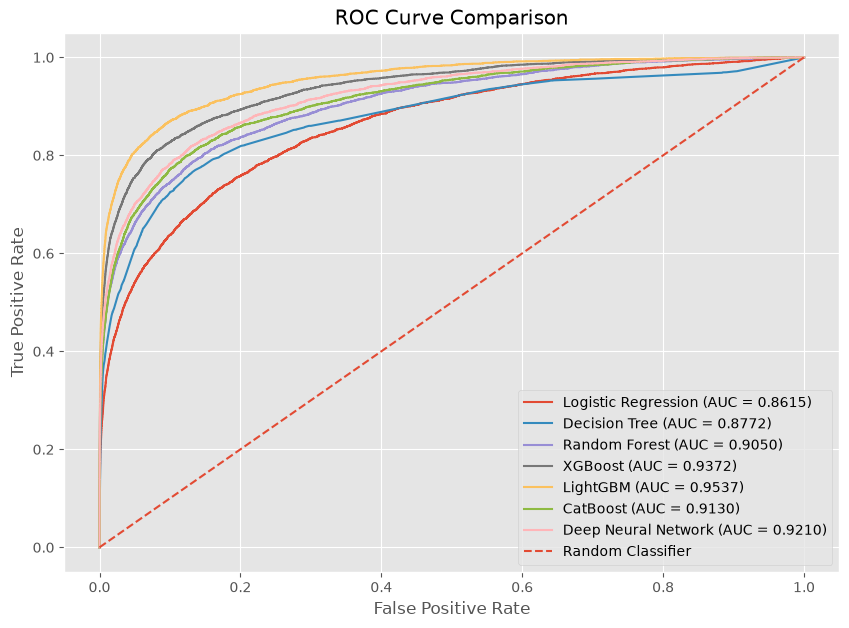

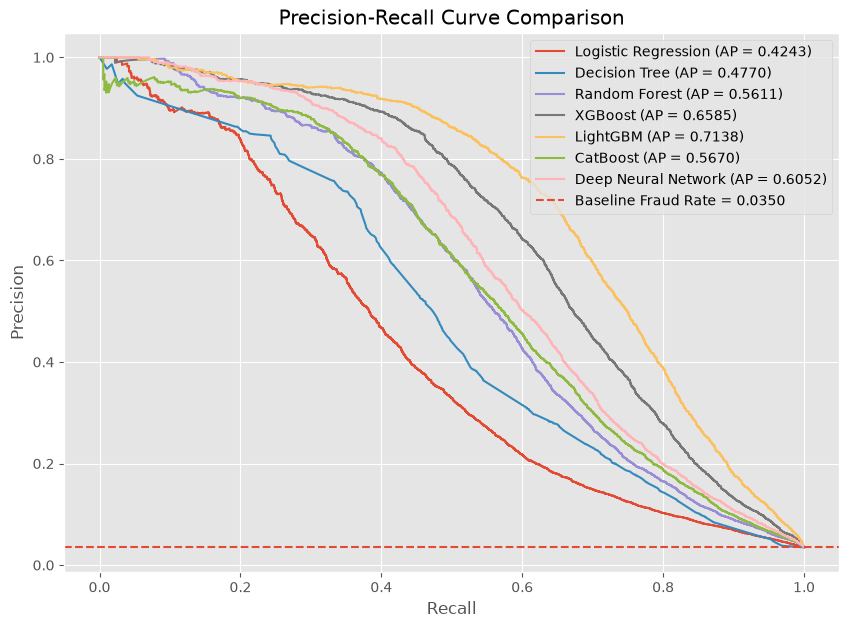

In [29]:
# ============================================================
# ROC Curve and Precision-Recall Curve Comparison
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# ------------------------------------------------------------
# Generate prediction probabilities for each model
# ------------------------------------------------------------

model_probabilities = {}

# Logistic Regression
if "log_reg_model" in globals():
    model_probabilities["Logistic Regression"] = log_reg_model.predict_proba(X_test_scaled)[:, 1]
elif "log_reg" in globals():
    model_probabilities["Logistic Regression"] = log_reg.predict_proba(X_test_scaled)[:, 1]

# Decision Tree
if "dt_model" in globals():
    model_probabilities["Decision Tree"] = dt_model.predict_proba(X_test)[:, 1]

# Random Forest
if "rf_model" in globals():
    model_probabilities["Random Forest"] = rf_model.predict_proba(X_test)[:, 1]

# XGBoost
if "xgb_model" in globals():
    model_probabilities["XGBoost"] = xgb_model.predict_proba(X_test)[:, 1]

# LightGBM
if "lgbm_model" in globals():
    model_probabilities["LightGBM"] = lgbm_model.predict_proba(X_test)[:, 1]

# CatBoost
if "cat_model" in globals():
    model_probabilities["CatBoost"] = cat_model.predict_proba(X_test)[:, 1]

# Deep Neural Network
if "dnn_model" in globals():
    model_probabilities["Deep Neural Network"] = dnn_model.predict(X_test_scaled).ravel()

print("Models included in curve comparison:")
for model_name in model_probabilities.keys():
    print("-", model_name)

# ------------------------------------------------------------
# ROC Curve Comparison
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

for model_name, y_score in model_probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# ------------------------------------------------------------
# Precision-Recall Curve Comparison
# ------------------------------------------------------------

plt.figure(figsize=(10, 7))

for model_name, y_score in model_probabilities.items():
    precision, recall, _ = precision_recall_curve(y_test, y_score)
    avg_precision = average_precision_score(y_test, y_score)
    plt.plot(recall, precision, label=f"{model_name} (AP = {avg_precision:.4f})")

baseline_precision = y_test.mean()
plt.axhline(
    y=baseline_precision,
    linestyle="--",
    label=f"Baseline Fraud Rate = {baseline_precision:.4f}"
)

plt.title("Precision-Recall Curve Comparison")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend(loc="upper right")
plt.grid(True)
plt.show()

3691/3691 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step


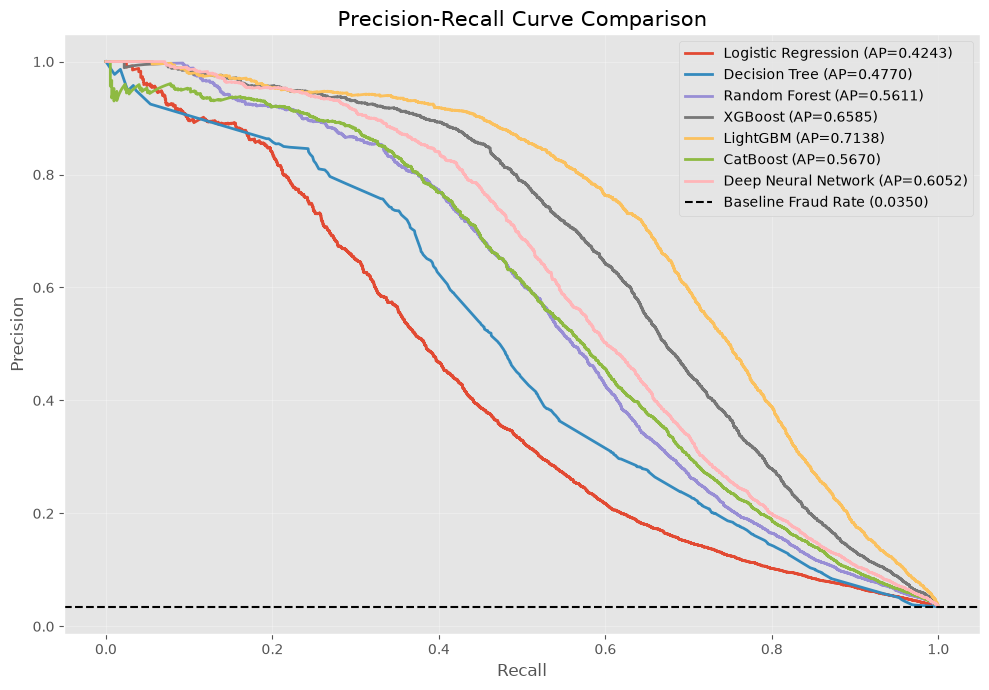

In [30]:
# ==========================================================
# Precision-Recall Curve Comparison
# ==========================================================

import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(10,7))

# Logistic Regression
if "log_reg_model" in globals():
    y_score = log_reg_model.predict_proba(X_test_scaled)[:,1]
elif "log_reg" in globals():
    y_score = log_reg.predict_proba(X_test_scaled)[:,1]

precision, recall, _ = precision_recall_curve(y_test, y_score)
ap = average_precision_score(y_test, y_score)
plt.plot(recall, precision, linewidth=2,
         label=f"Logistic Regression (AP={ap:.4f})")

# Decision Tree
y_score = dt_model.predict_proba(X_test)[:,1]
precision, recall, _ = precision_recall_curve(y_test, y_score)
ap = average_precision_score(y_test, y_score)
plt.plot(recall, precision, linewidth=2,
         label=f"Decision Tree (AP={ap:.4f})")

# Random Forest
y_score = rf_model.predict_proba(X_test)[:,1]
precision, recall, _ = precision_recall_curve(y_test, y_score)
ap = average_precision_score(y_test, y_score)
plt.plot(recall, precision, linewidth=2,
         label=f"Random Forest (AP={ap:.4f})")

# XGBoost
y_score = xgb_model.predict_proba(X_test)[:,1]
precision, recall, _ = precision_recall_curve(y_test, y_score)
ap = average_precision_score(y_test, y_score)
plt.plot(recall, precision, linewidth=2,
         label=f"XGBoost (AP={ap:.4f})")

# LightGBM
y_score = lgbm_model.predict_proba(X_test)[:,1]
precision, recall, _ = precision_recall_curve(y_test, y_score)
ap = average_precision_score(y_test, y_score)
plt.plot(recall, precision, linewidth=2,
         label=f"LightGBM (AP={ap:.4f})")

# CatBoost
y_score = cat_model.predict_proba(X_test)[:,1]
precision, recall, _ = precision_recall_curve(y_test, y_score)
ap = average_precision_score(y_test, y_score)
plt.plot(recall, precision, linewidth=2,
         label=f"CatBoost (AP={ap:.4f})")

# Deep Neural Network
if "dnn_model" in globals():
    y_score = dnn_model.predict(X_test_scaled).ravel()
    precision, recall, _ = precision_recall_curve(y_test, y_score)
    ap = average_precision_score(y_test, y_score)
    plt.plot(recall, precision, linewidth=2,
             label=f"Deep Neural Network (AP={ap:.4f})")

# Baseline fraud rate
plt.axhline(
    y=y_test.mean(),
    linestyle="--",
    color="black",
    label=f"Baseline Fraud Rate ({y_test.mean():.4f})"
)

plt.title("Precision-Recall Curve Comparison", fontsize=15)
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [31]:
# LightGBM Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": lgbm_model.feature_importances_
}).sort_values("Importance", ascending=False)

feature_importance.head(30)

,Feature,Importance
2,card1,1165
3,card2,867
419,TransactionDay,826
8,addr1,730
0,TransactionAmt,683
25,C13,562
40,D15,444
27,D1,433
11,P_emaildomain,382
6,card5,378


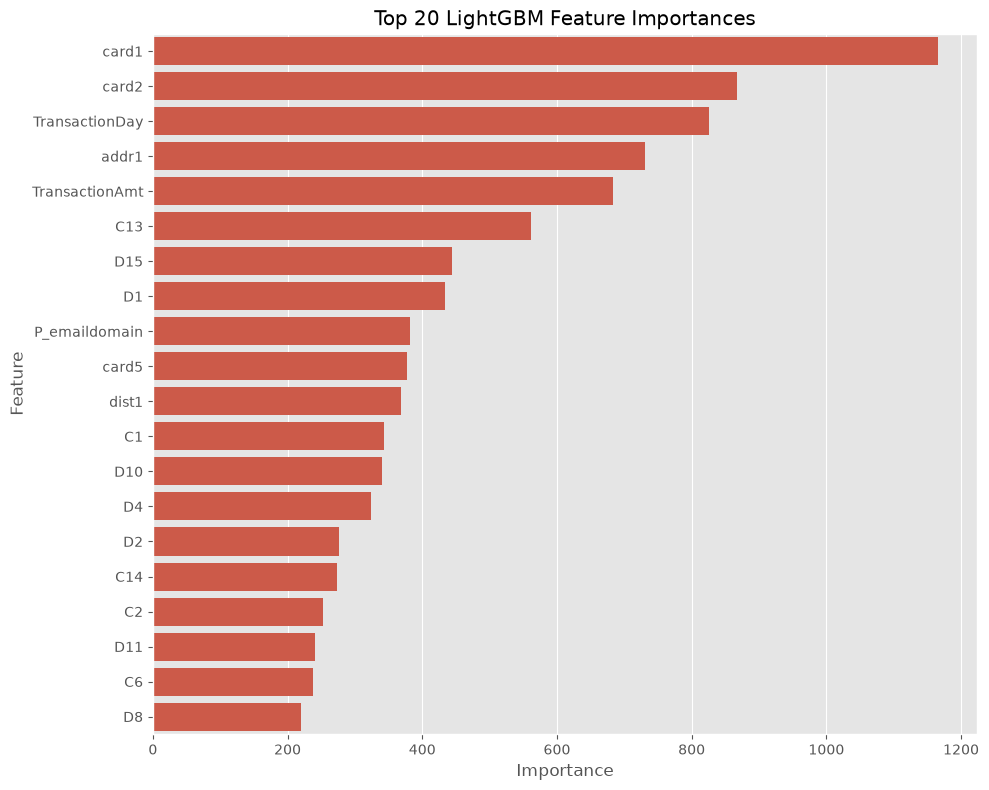

In [33]:
import seaborn as sns
plt.figure(figsize=(10, 8))

sns.barplot(
    data=feature_importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 LightGBM Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [34]:
xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False)

xgb_importance.head(30)

,Feature,Importance
307,V258,0.112677
267,V218,0.084724
140,V91,0.071125
119,V70,0.066434
250,V201,0.041378
343,V294,0.032485
357,V308,0.015036
20,C8,0.014225
97,V48,0.011832
26,C14,0.010613


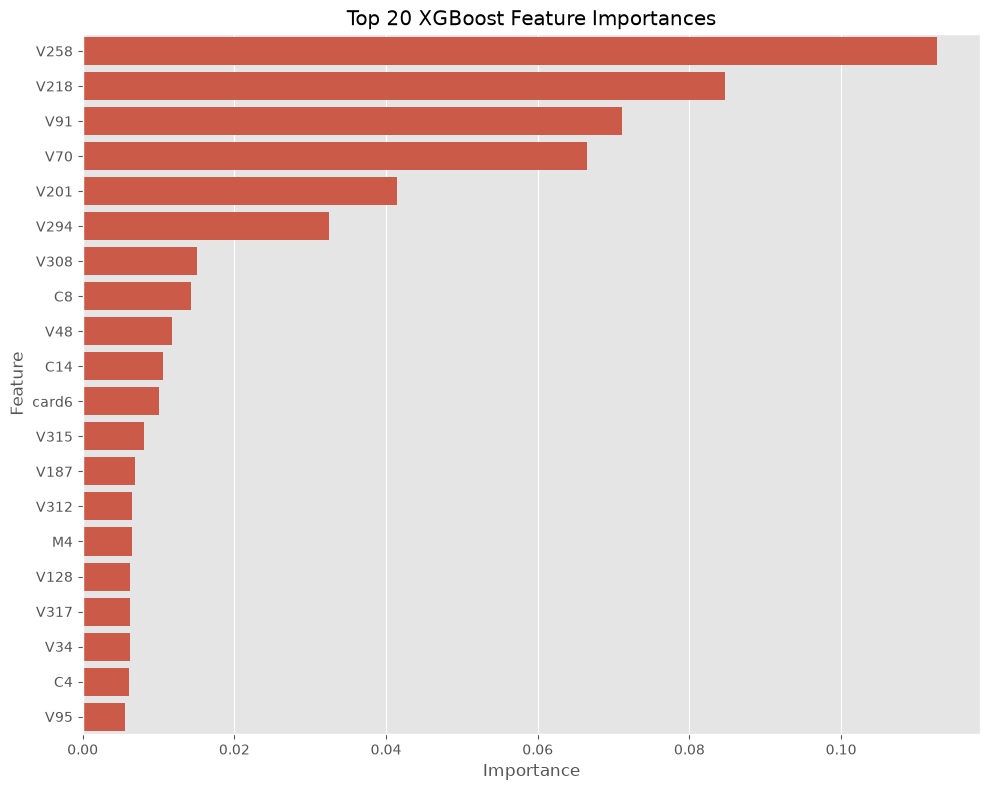

In [35]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=xgb_importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [36]:
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

rf_importance.head(30)

,Feature,Importance
140,V91,0.031640
25,C13,0.028101
26,C14,0.027273
139,V90,0.026959
78,V29,0.019261
366,V317,0.018998
307,V258,0.018059
267,V218,0.018004
12,R_emaildomain,0.017672
0,TransactionAmt,0.017244


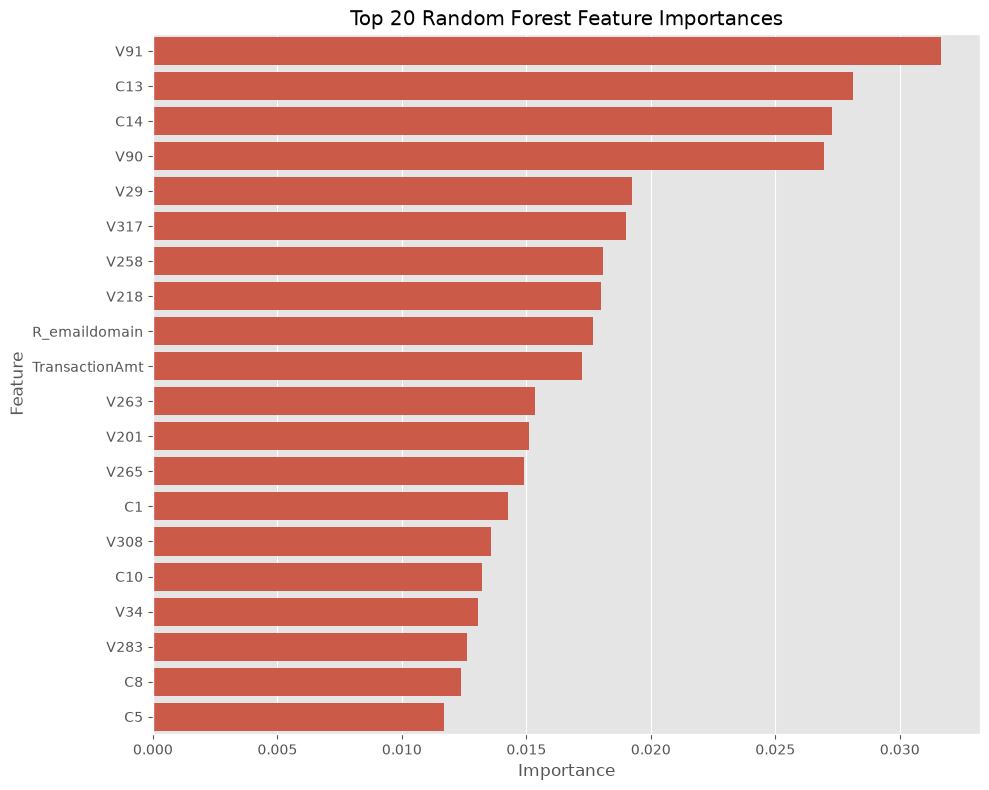

In [37]:
plt.figure(figsize=(10, 8))

sns.barplot(
    data=rf_importance.head(20),
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

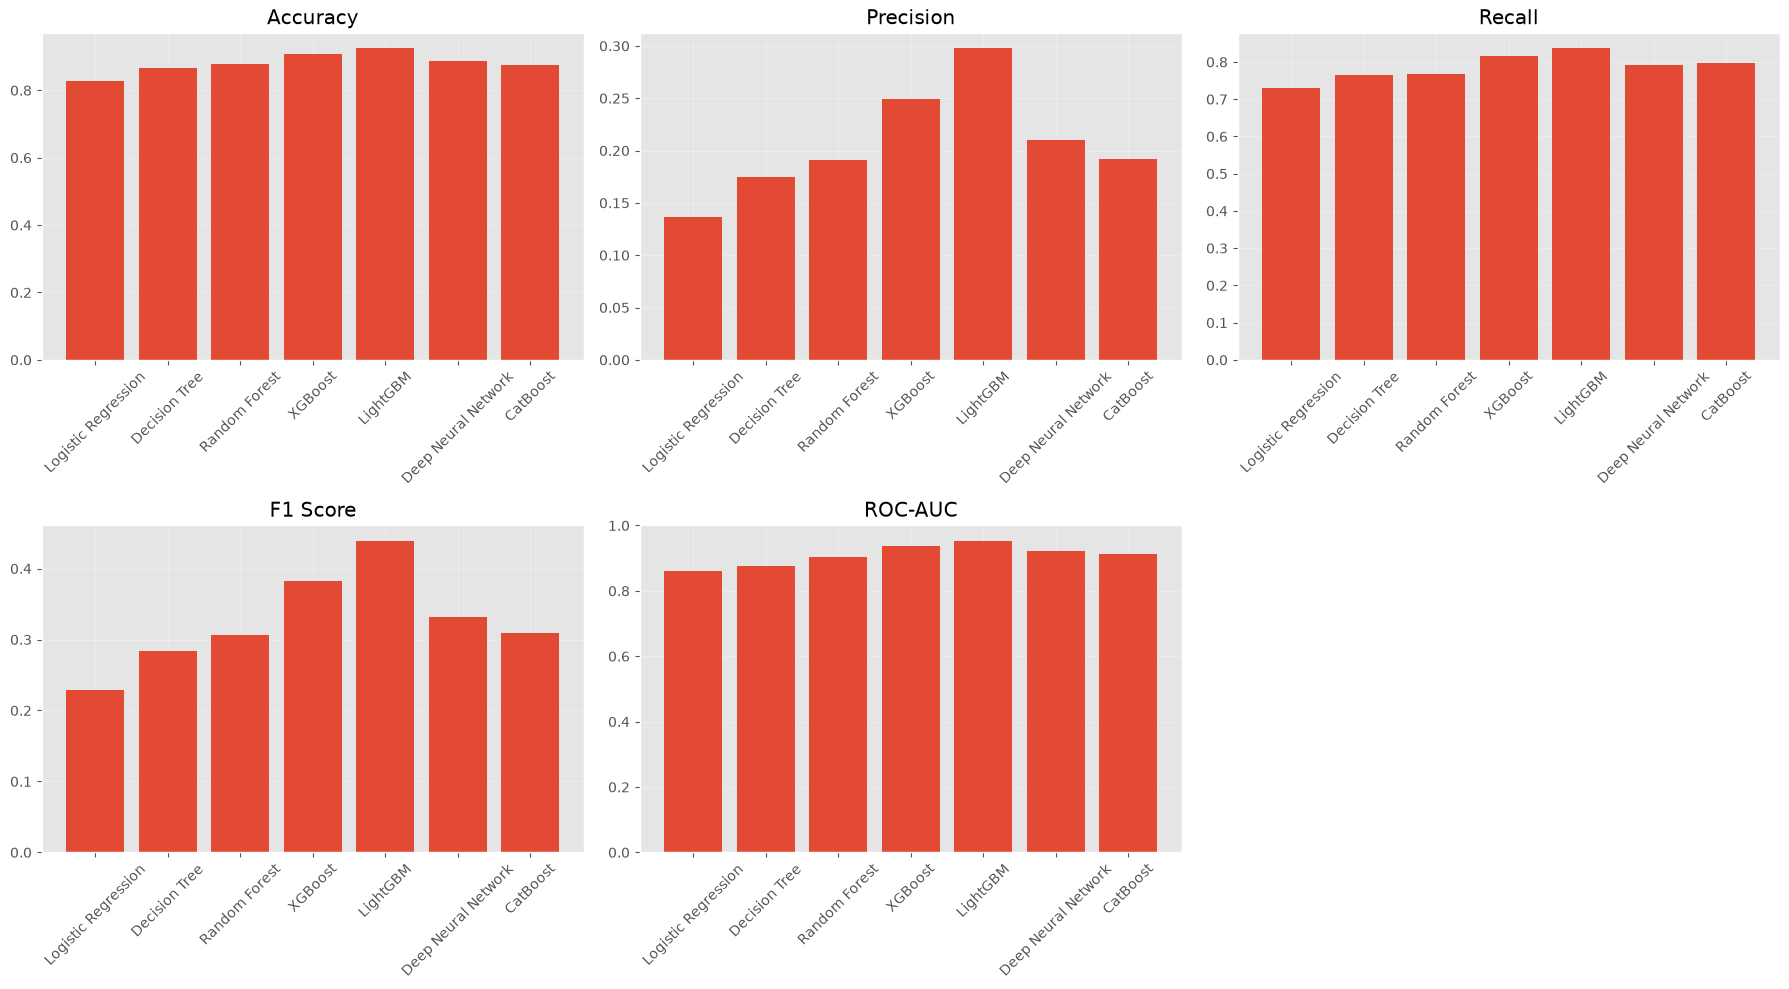

In [38]:
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    axes[i].bar(model_results["Model"], model_results[metric])
    axes[i].set_title(metric)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(alpha=0.3)

# Remove unused subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

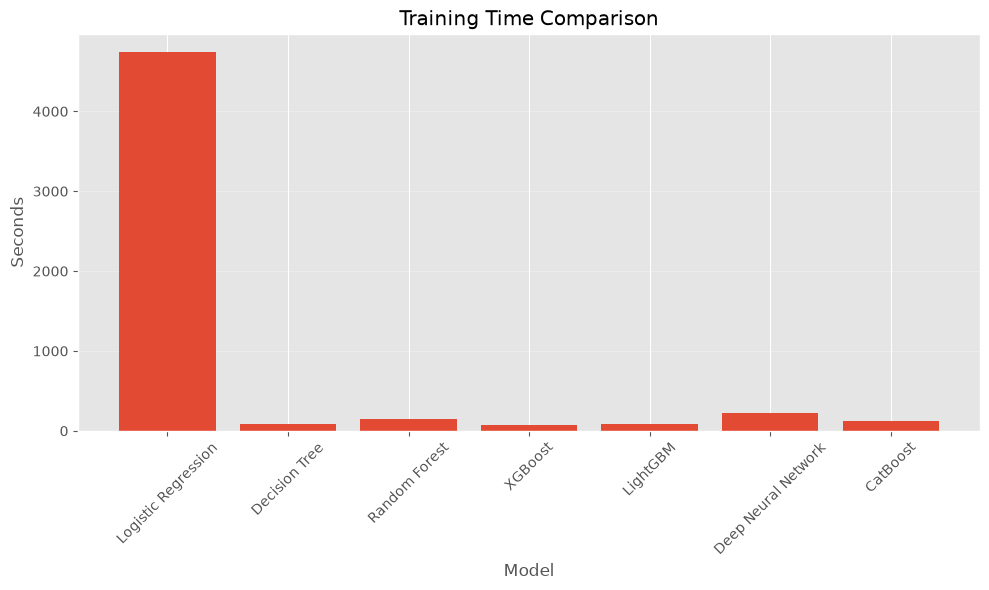

In [39]:
plt.figure(figsize=(10,6))

plt.bar(
    model_results["Model"],
    model_results["Training Time (s)"]
)

plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Seconds")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()